In [1]:
import numpy as np
import matplotlib.pyplot as plt
import alphashape
from shapely.plotting import plot_polygon
import lal
import json

plt.style.use("~/PhD/subdom_asym/code_subdom_asym/MATPLOTLIB_RCPARAMS.sty")

In [2]:
# import json file
with open('dolphin_data.json') as json_file:
    data = json.load(json_file)

for key, value in data.items():
        locals()[key] = np.array(value)


#speed of light in km/s
c = lal.C_SI*1e-3         

vz_all_modes_copr = vs_all_modes_copr*c
vs_22_modes_copr = vs_22_modes_copr*c

theta1s = np.ndarray.flatten(THETA1)
phi1s = np.ndarray.flatten(PHI1)
theta2s = np.ndarray.flatten(THETA2)
phi2s = np.ndarray.flatten(PHI2)

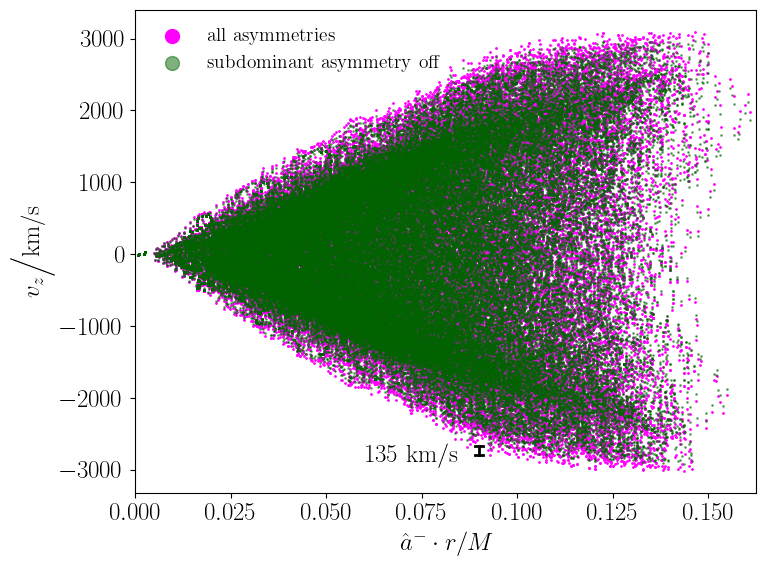

In [3]:
fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111)

# main scatter plot
ax1.scatter(max_minus_copr, vz_all_modes_copr, s=1, color='magenta', rasterized=True, label='all asymmetries') 
ax1.scatter(max_minus_copr, vs_22_modes_copr, s=1, color='darkgreen', rasterized=True, label='subdominant asymmetry off', alpha=.5)
ax1.set_xlabel(r'$\hat{a}^-\cdot r/M$')
ax1.set_ylabel(r'$v_z\Big/$km/s')
ax1.legend(frameon=False, markerscale=10, fontsize=14)
ax1.set_xlim(0., 0.1625)


# # Alpha-Shape for all multipoles
# points_all = list(zip(max_minus_copr, vz_all_modes_copr))
# alpha_all = alphashape.alphashape(points_all, 1e-8)
# plot_polygon(alpha_all, ax=ax1, alpha=0.2, color='magenta', add_points=False)


# # Alpha-Shape for (2,±2) only
# points_22 = list(zip(max_minus_copr, vs_22_modes_copr))
# alpha_22 = alphashape.alphashape(points_22, 1e-8)
# plot_polygon(alpha_22, ax=ax1, alpha=0.2, color='darkgreen', add_points=False)


# veritical line
x_pos = 0.09   
y_start = -2800 
y_length = 135  
tick_width = 0.001

ax1.plot([x_pos, x_pos],
         [y_start, y_start + y_length],
         color='black', lw=2)

ax1.plot([x_pos - tick_width, x_pos + tick_width],
         [y_start + y_length, y_start + y_length],
         color='black', lw=2)

ax1.plot([x_pos - tick_width, x_pos + tick_width],
         [y_start, y_start],
         color='black', lw=2)

ax1.text(x_pos - 0.005,                  
         y_start,              
         r'$135\ \mathrm{km/s}$',
         va='center', ha='right') 


fig.tight_layout()
# fig.savefig('sak_q1_2spin_subdom_asym.pdf')
plt.show()

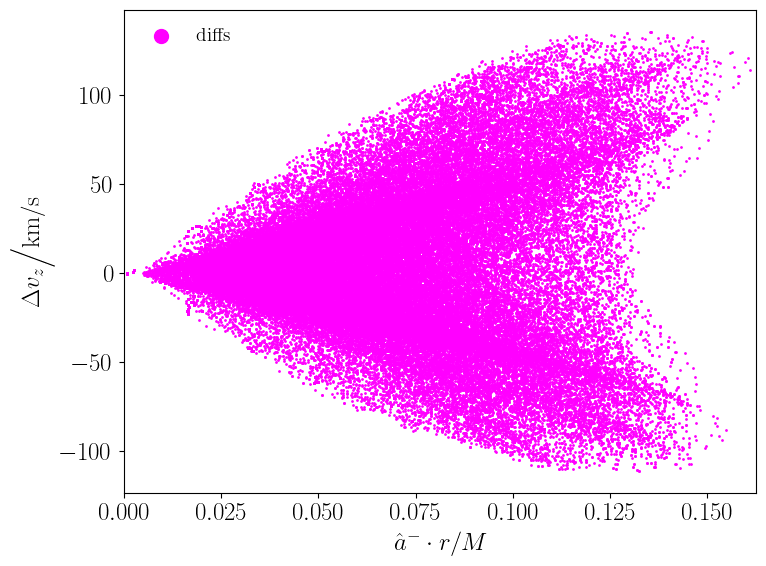

In [4]:
fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111)

# main scatter plot
ax1.scatter(max_minus_copr, vz_all_modes_copr - vs_22_modes_copr, s=1, color='magenta', rasterized=True, label='diffs') 
ax1.set_xlabel(r'$\hat{a}^-\cdot r/M$')
ax1.set_ylabel(r'$\Delta v_z\Big/$km/s')
ax1.legend(frameon=False, markerscale=10, fontsize=14)
ax1.set_xlim(0., 0.1625)


# # Alpha-Shape for all multipoles
# points_all = list(zip(max_minus_copr, vz_all_modes_copr))
# alpha_all = alphashape.alphashape(points_all, 1e-8)
# plot_polygon(alpha_all, ax=ax1, alpha=0.2, color='magenta', add_points=False)


# # Alpha-Shape for (2,±2) only
# points_22 = list(zip(max_minus_copr, vs_22_modes_copr))
# alpha_22 = alphashape.alphashape(points_22, 1e-8)
# plot_polygon(alpha_22, ax=ax1, alpha=0.2, color='darkgreen', add_points=False)


# veritical line
# x_pos = 0.09   
# y_start = -2800 
# y_length = 135  
# tick_width = 0.001

# ax1.plot([x_pos, x_pos],
#          [y_start, y_start + y_length],
#          color='black', lw=2)

# ax1.plot([x_pos - tick_width, x_pos + tick_width],
#          [y_start + y_length, y_start + y_length],
#          color='black', lw=2)

# ax1.plot([x_pos - tick_width, x_pos + tick_width],
#          [y_start, y_start],
#          color='black', lw=2)

# ax1.text(x_pos - 0.005,                  
#          y_start,              
#          r'$135\ \mathrm{km/s}$',
#          va='center', ha='right') 


fig.tight_layout()
# fig.savefig('sak_q1_2spin_subdom_asym.pdf')
plt.show()

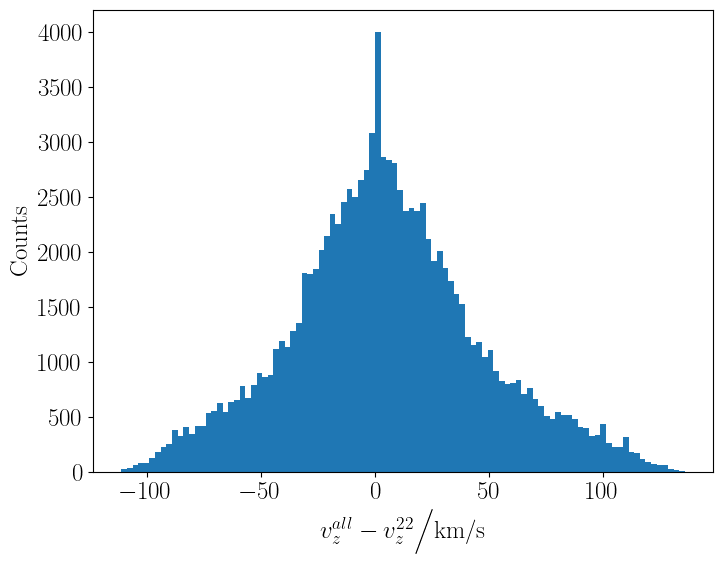

In [5]:
plt.figure(figsize=(8,6))
plt.hist(vz_all_modes_copr - vs_22_modes_copr, bins=100)
plt.xlabel(r'$v_z^{all} - v_z^{22}\Big/$km/s')
plt.ylabel('Counts')
plt.show()

In [6]:
diffs = vz_all_modes_copr - vs_22_modes_copr
max_vz_all = np.max(vz_all_modes_copr)
max_diff = np.max(np.abs(vz_all_modes_copr - vs_22_modes_copr))
ratio = max_diff / max_vz_all 
threshold = 100  # km/s
fraction = np.sum(np.abs(diffs) > threshold) / len(diffs)

print(f"Max of vz_all_modes_copr: {max_vz_all:.2f} km/s")
print(f"Max of |diffs|: {max_diff:.2f} km/s")
print(f"Ratio max(|diffs| / max(vz_all_modes_copr) /): {ratio:.2f}")
print(f"Fraction of configurations with |Δv_z| > {threshold} km/s: {fraction:.2%}")

Max of vz_all_modes_copr: 3091.99 km/s
Max of |diffs|: 135.75 km/s
Ratio max(|diffs| / max(vz_all_modes_copr) /): 0.04
Fraction of configurations with |Δv_z| > 100 km/s: 2.17%
